# Model experiments: Feature Extraction vs Full Fine-tuning vs LoRA vs QLoRA

This notebook keeps the model code visible in one place. Run `Preprocessing.ipynb` first so the processed Rotten Tomatoes files exist under `Data/processed/`.

Recommended flow:
1. Run setup cells.
2. Review the four method sections or run any single-method cell if needed.
3. Run the final all-methods cell.
4. Review the final summary table and comparison plots.


## 1. Imports and paths

In [15]:
from pathlib import Path
from dataclasses import dataclass
from inspect import signature
import importlib.util
import json
import random
import time
import traceback

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import Dataset, DatasetDict
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments, set_seed as set_transformers_seed

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name.lower() == "notebook" else Path.cwd()
DATA_DIR = PROJECT_ROOT / "Data" / "processed"
OUTPUT_DIR = PROJECT_ROOT / "Output"
FIGURES_DIR = OUTPUT_DIR / "figures"
METRICS_DIR = OUTPUT_DIR / "metrics"
RESULTS_DIR = OUTPUT_DIR / "results"
WEIGHTS_DIR = OUTPUT_DIR / "model_weights"

for path in [FIGURES_DIR, METRICS_DIR, RESULTS_DIR, WEIGHTS_DIR]:
    path.mkdir(parents=True, exist_ok=True)

PROJECT_ROOT 

WindowsPath('c:/my/Projectes/DeepLearning/Bert-LORA-QLORA-imdb')

## 2. Experiment config

Start with a small `SAMPLE_SIZE` to test everything. Set `SAMPLE_SIZE = None` for the full Rotten Tomatoes splits.

In [16]:
MODEL_NAME = "bert-base-uncased"
RUN_LABEL = "notebook"
SEED = 42
MAX_LENGTH = 128
EPOCHS = 5
SAMPLE_SIZE = None  # Use None for full data.

COMMON_BATCH_SIZE = 4  # Increase to 8 if GPU memory allows.
FEATURE_EXTRACTION_LR = 1e-3
FULL_FINETUNE_LR = 2e-5
LORA_LR = 2e-4
QLORA_LR = 2e-4

LORA_R = 16
LORA_ALPHA = 16
LORA_DROPOUT = 0.1

USE_FP16 = False
USE_GRADIENT_CHECKPOINTING = False
FINAL_TEST_EVALUATION = True

SEEDS = [13, 42, 77]
RUN_MULTI_SEED_EXPERIMENTS = False
IS_OFFICIAL_RUN = True

DEVICE_INFO = torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU"
DEVICE_INFO

'NVIDIA GeForce RTX 3050 Laptop GPU'

## 3. Data loading and tokenization

In [17]:
def set_global_seed(seed: int = SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    set_transformers_seed(seed)


def load_processed_splits(sample_size: int | None = SAMPLE_SIZE, seed: int = SEED) -> DatasetDict:
    paths = {
        "train": DATA_DIR / "train.parquet",
        "validation": DATA_DIR / "validation.parquet",
        "test": DATA_DIR / "test.parquet",
    }
    missing = [str(path) for path in paths.values() if not path.exists()]
    if missing:
        raise FileNotFoundError(f"Run Notebook/Preprocessing.ipynb first. Missing files: {missing}")

    frames = {}
    for split, path in paths.items():
        df = pd.read_parquet(path)[["text", "label"]].dropna()
        df["text"] = df["text"].astype(str)
        df["label"] = df["label"].astype(int)
        if sample_size:
            per_class = min(sample_size // 2, df["label"].value_counts().min())
            df = (
                df.groupby("label", group_keys=False)
                .sample(n=per_class, random_state=seed)
                .sample(frac=1, random_state=seed)
                .reset_index(drop=True)
            )
        frames[split] = Dataset.from_pandas(df, preserve_index=False)
    return DatasetDict(frames)


def tokenize_dataset(sample_size: int | None = SAMPLE_SIZE, max_length: int = MAX_LENGTH, seed: int = SEED):
    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
    dataset = load_processed_splits(sample_size=sample_size, seed=seed)

    def tokenize_batch(batch):
        return tokenizer(batch["text"], padding="max_length", truncation=True, max_length=max_length)

    tokenized = dataset.map(tokenize_batch, batched=True, remove_columns=["text"])
    for split in tokenized:
        tokenized[split] = tokenized[split].rename_column("label", "labels")
    return tokenized, tokenizer


raw_preview = load_processed_splits(sample_size=5)
raw_preview

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 4
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 4
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 4
    })
})

## 4. Metrics and saving helpers

In [18]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "precision": precision_score(labels, preds, zero_division=0),
        "recall": recall_score(labels, preds, zero_division=0),
        "f1": f1_score(labels, preds, zero_division=0),
        "f1_macro": f1_score(labels, preds, average="macro", zero_division=0),
    }


def count_parameters(model):
    if hasattr(model, "get_nb_trainable_parameters"):
        trainable, total = model.get_nb_trainable_parameters()
    else:
        total = sum(p.numel() for p in model.parameters())
        trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return {
        "total_parameters": int(total),
        "trainable_parameters": int(trainable),
        "trainable_percent": round((trainable / total) * 100, 4),
    }


def cleanup_memory():
    import gc

    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats()


def reset_gpu_memory():
    cleanup_memory()


def gpu_memory_metrics_mb():
    if not torch.cuda.is_available():
        return {
            "peak_gpu_memory_mb": None,
            "peak_gpu_allocated_mb": None,
            "peak_gpu_reserved_mb": None,
        }
    allocated = round(torch.cuda.max_memory_allocated() / (1024 ** 2), 2)
    reserved = round(torch.cuda.max_memory_reserved() / (1024 ** 2), 2)
    return {
        "peak_gpu_memory_mb": allocated,
        "peak_gpu_allocated_mb": allocated,
        "peak_gpu_reserved_mb": reserved,
    }


def peak_gpu_memory_mb():
    return gpu_memory_metrics_mb()["peak_gpu_memory_mb"]


def save_metrics(run_name: str, payload: dict):
    metrics_path = METRICS_DIR / f"{run_name}_metrics.json"
    with open(metrics_path, "w", encoding="utf-8") as f:
        json.dump(payload, f, indent=2)
    return metrics_path


SUMMARY_COLUMNS = [
    "run_name", "run_label", "method", "seed", "status", "is_official_run",
    "dataset_train_rows", "dataset_validation_rows", "dataset_test_rows",
    "sample_size", "epochs", "batch_size", "learning_rate", "max_length",
    "final_test_evaluation", "evaluation_split",
    "accuracy", "precision", "recall", "f1", "f1_macro",
    "validation_accuracy", "validation_precision", "validation_recall", "validation_f1", "validation_f1_macro", "validation_loss",
    "test_accuracy", "test_precision", "test_recall", "test_f1", "test_f1_macro", "test_loss",
    "training_time_seconds", "peak_gpu_memory_mb", "peak_gpu_allocated_mb", "peak_gpu_reserved_mb", "model_dir",
    "total_parameters", "trainable_parameters", "trainable_percent",
    "log_history_path", "confusion_matrix_path", "error_file",
]


def append_summary(row: dict):
    summary_path = RESULTS_DIR / "summary_results.csv"
    new_row = pd.DataFrame([row]).reindex(columns=SUMMARY_COLUMNS)
    if summary_path.exists():
        existing = pd.read_csv(summary_path).reindex(columns=SUMMARY_COLUMNS)
        new_row = pd.concat([existing, new_row], ignore_index=True)
    new_row.to_csv(summary_path, index=False)
    return summary_path

## 5. Shared Trainer runner

In [19]:
def apply_gradient_checkpointing_setting(model):
    if USE_GRADIENT_CHECKPOINTING and hasattr(model, "gradient_checkpointing_enable"):
        model.gradient_checkpointing_enable()
    elif not USE_GRADIENT_CHECKPOINTING and hasattr(model, "gradient_checkpointing_disable"):
        model.gradient_checkpointing_disable()
    if hasattr(model, "config") and hasattr(model.config, "use_cache"):
        model.config.use_cache = not USE_GRADIENT_CHECKPOINTING
    return model


@dataclass
class RunConfig:
    method: str
    batch_size: int
    learning_rate: float
    epochs: float = EPOCHS
    seed: int = SEED
    max_length: int = MAX_LENGTH
    sample_size: int | None = SAMPLE_SIZE
    fp16: bool = USE_FP16
    run_label: str = RUN_LABEL
    is_official_run: bool = IS_OFFICIAL_RUN
    final_test_evaluation: bool = FINAL_TEST_EVALUATION


def training_args(config: RunConfig, run_dir: Path):
    args = {
        "output_dir": str(run_dir),
        "learning_rate": config.learning_rate,
        "per_device_train_batch_size": config.batch_size,
        "per_device_eval_batch_size": config.batch_size,
        "num_train_epochs": config.epochs,
        "weight_decay": 0.01,
        "logging_strategy": "steps",
        "logging_steps": 0.1,  # Log every 10% of total training steps.
        "save_strategy": "epoch",
        "load_best_model_at_end": True,
        "metric_for_best_model": "f1",
        "greater_is_better": True,
        "save_total_limit": 1,
        "report_to": "none",
        "fp16": bool(config.fp16),
        "seed": config.seed,
        "data_seed": config.seed,
    }
    if "eval_strategy" in signature(TrainingArguments.__init__).parameters:
        args["eval_strategy"] = "epoch"
    else:
        args["evaluation_strategy"] = "epoch"
    return TrainingArguments(**args)


def metric_value(metrics: dict, prefix: str, name: str):
    return metrics.get(f"{prefix}_{name}")


def train_and_evaluate(model, tokenizer, config: RunConfig):
    run_name = f"{config.run_label}_{config.method}_seed_{config.seed}"
    run_dir = WEIGHTS_DIR / run_name
    tokenized, tokenizer = tokenize_dataset(sample_size=config.sample_size, max_length=config.max_length, seed=config.seed)
    params = count_parameters(model)
    print(f"{config.method} parameter counts:", params)

    trainer = Trainer(
        model=model,
        args=training_args(config, run_dir),
        train_dataset=tokenized["train"],
        eval_dataset=tokenized["validation"],
        tokenizer=tokenizer,
        compute_metrics=compute_metrics,
    )

    cleanup_memory()
    if torch.cuda.is_available():
        torch.cuda.synchronize()
    start_time = time.perf_counter()
    train_result = trainer.train()
    if torch.cuda.is_available():
        torch.cuda.synchronize()
    training_time = round(time.perf_counter() - start_time, 2)

    validation_metrics = trainer.evaluate(tokenized["validation"], metric_key_prefix="validation")
    test_metrics = {}
    evaluation_split = "validation"
    primary_metrics = validation_metrics
    primary_prefix = "validation"
    if config.final_test_evaluation:
        test_metrics = trainer.evaluate(tokenized["test"], metric_key_prefix="test")
        evaluation_split = "test"
        primary_metrics = test_metrics
        primary_prefix = "test"

    final_dir = run_dir / "final"
    trainer.save_model(str(final_dir))
    tokenizer.save_pretrained(str(final_dir))

    prediction_split = tokenized[evaluation_split]
    predictions_output = trainer.predict(prediction_split, metric_key_prefix=evaluation_split)
    predictions = np.argmax(predictions_output.predictions, axis=-1)
    cm = confusion_matrix(predictions_output.label_ids, predictions).tolist()
    confusion_matrix_path = METRICS_DIR / f"{run_name}_{evaluation_split}_confusion_matrix.json"
    confusion_matrix_path.write_text(
        json.dumps({"split": evaluation_split, "labels": [0, 1], "matrix": cm}, indent=2),
        encoding="utf-8",
    )

    log_history_path = METRICS_DIR / f"{run_name}_log_history.csv"
    pd.DataFrame(trainer.state.log_history).to_csv(log_history_path, index=False)

    memory_metrics = gpu_memory_metrics_mb()
    row = {
        "run_name": run_name,
        "run_label": config.run_label,
        "method": config.method,
        "seed": config.seed,
        "status": "ok",
        "is_official_run": bool(config.is_official_run),
        "dataset_train_rows": len(tokenized["train"]),
        "dataset_validation_rows": len(tokenized["validation"]),
        "dataset_test_rows": len(tokenized["test"]),
        "sample_size": config.sample_size,
        "epochs": config.epochs,
        "batch_size": config.batch_size,
        "learning_rate": config.learning_rate,
        "max_length": config.max_length,
        "final_test_evaluation": bool(config.final_test_evaluation),
        "evaluation_split": evaluation_split,
        "accuracy": metric_value(primary_metrics, primary_prefix, "accuracy"),
        "precision": metric_value(primary_metrics, primary_prefix, "precision"),
        "recall": metric_value(primary_metrics, primary_prefix, "recall"),
        "f1": metric_value(primary_metrics, primary_prefix, "f1"),
        "f1_macro": metric_value(primary_metrics, primary_prefix, "f1_macro"),
        "validation_accuracy": metric_value(validation_metrics, "validation", "accuracy"),
        "validation_precision": metric_value(validation_metrics, "validation", "precision"),
        "validation_recall": metric_value(validation_metrics, "validation", "recall"),
        "validation_f1": metric_value(validation_metrics, "validation", "f1"),
        "validation_f1_macro": metric_value(validation_metrics, "validation", "f1_macro"),
        "validation_loss": metric_value(validation_metrics, "validation", "loss"),
        "test_accuracy": metric_value(test_metrics, "test", "accuracy"),
        "test_precision": metric_value(test_metrics, "test", "precision"),
        "test_recall": metric_value(test_metrics, "test", "recall"),
        "test_f1": metric_value(test_metrics, "test", "f1"),
        "test_f1_macro": metric_value(test_metrics, "test", "f1_macro"),
        "test_loss": metric_value(test_metrics, "test", "loss"),
        "training_time_seconds": training_time,
        "model_dir": str(final_dir),
        "log_history_path": str(log_history_path),
        "confusion_matrix_path": str(confusion_matrix_path),
        **memory_metrics,
        **params,
    }
    save_metrics(
        run_name,
        {
            "config": config.__dict__,
            "train": train_result.metrics,
            "validation": validation_metrics,
            "test": test_metrics,
            "summary": row,
        },
    )
    append_summary(row)
    return row

## 6. Feature Extraction only

BERT is frozen. Only the classification head is trained.

In [20]:
def build_feature_extraction_model(seed: int = SEED):
    set_global_seed(seed)
    model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)
    for param in model.bert.parameters():
        param.requires_grad = False
    return model


def run_feature_extraction(seed: int = SEED, is_official_run: bool = IS_OFFICIAL_RUN):
    cleanup_memory()
    set_global_seed(seed)
    model = build_feature_extraction_model(seed=seed)
    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
    config = RunConfig(
        method="feature_extraction",
        batch_size=COMMON_BATCH_SIZE,
        learning_rate=FEATURE_EXTRACTION_LR,
        seed=seed,
        is_official_run=is_official_run,
    )
    return train_and_evaluate(model, tokenizer, config)


# Optional single-method run:
# feature_result = run_feature_extraction()
# pd.DataFrame([feature_result]).T

## 7. Full Fine-tuning only

All BERT parameters are trainable.

In [21]:
def build_finetune_model(seed: int = SEED):
    set_global_seed(seed)
    return AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)


def run_finetune(seed: int = SEED, is_official_run: bool = IS_OFFICIAL_RUN):
    cleanup_memory()
    set_global_seed(seed)
    model = build_finetune_model(seed=seed)
    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
    config = RunConfig(method="finetune", batch_size=COMMON_BATCH_SIZE, learning_rate=FULL_FINETUNE_LR, seed=seed, is_official_run=is_official_run)
    return train_and_evaluate(model, tokenizer, config)


# Optional single-method run:
# finetune_result = run_finetune()
# pd.DataFrame([finetune_result]).T

## 8. LoRA only

BERT is frozen and small LoRA adapters are trained on attention `query` and `value` modules.

In [22]:
def build_lora_model(seed: int = SEED):
    set_global_seed(seed)
    from peft import LoraConfig, TaskType, get_peft_model

    model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)
    model = apply_gradient_checkpointing_setting(model)
    lora_config = LoraConfig(
        task_type=TaskType.SEQ_CLS,
        r=LORA_R,
        lora_alpha=LORA_ALPHA,
        lora_dropout=LORA_DROPOUT,
        target_modules=["query", "value"],
        modules_to_save=["classifier"],
    )
    return apply_gradient_checkpointing_setting(get_peft_model(model, lora_config))


def run_lora(seed: int = SEED, is_official_run: bool = IS_OFFICIAL_RUN):
    cleanup_memory()
    set_global_seed(seed)
    model = build_lora_model(seed=seed)
    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
    config = RunConfig(method="lora", batch_size=COMMON_BATCH_SIZE, learning_rate=LORA_LR, seed=seed, is_official_run=is_official_run)
    return train_and_evaluate(model, tokenizer, config)


# Optional single-method run:
# lora_result = run_lora()
# pd.DataFrame([lora_result]).T

## 9. QLoRA only

This needs a working CUDA + bitsandbytes setup. If it fails on native Windows, run this cell on WSL2, Linux, Colab, or Kaggle.

In [23]:
def build_qlora_model(seed: int = SEED):
    set_global_seed(seed)
    if not torch.cuda.is_available():
        raise RuntimeError("QLoRA requires CUDA.")
    if importlib.util.find_spec("bitsandbytes") is None:
        raise RuntimeError("bitsandbytes is not installed.")

    from peft import LoraConfig, TaskType, get_peft_model, prepare_model_for_kbit_training
    from transformers import BitsAndBytesConfig

    quant_config = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_quant_type="nf4",
        bnb_4bit_compute_dtype=torch.float32,
    )
    model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME,
        num_labels=2,
        quantization_config=quant_config,
    )
    model = prepare_model_for_kbit_training(model, use_gradient_checkpointing=USE_GRADIENT_CHECKPOINTING)
    model = apply_gradient_checkpointing_setting(model)
    lora_config = LoraConfig(
        task_type=TaskType.SEQ_CLS,
        r=LORA_R,
        lora_alpha=LORA_ALPHA,
        lora_dropout=LORA_DROPOUT,
        target_modules=["query", "value"],
        modules_to_save=["classifier"],
    )
    return apply_gradient_checkpointing_setting(get_peft_model(model, lora_config))


def run_qlora(seed: int = SEED, is_official_run: bool = IS_OFFICIAL_RUN):
    cleanup_memory()
    set_global_seed(seed)
    model = build_qlora_model(seed=seed)
    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
    config = RunConfig(method="qlora", batch_size=COMMON_BATCH_SIZE, learning_rate=QLORA_LR, seed=seed, is_official_run=is_official_run)
    return train_and_evaluate(model, tokenizer, config)


# Optional single-method run:
# try:
#     qlora_result = run_qlora()
# except Exception as exc:
#     error_path = METRICS_DIR / f"{RUN_LABEL}_qlora_error_seed_{SEED}.txt"
#     error_path.write_text(traceback.format_exc(), encoding="utf-8")
#     qlora_result = {"run_name": f"{RUN_LABEL}_qlora_seed_{SEED}", "run_label": RUN_LABEL, "method": "qlora", "seed": SEED, "status": "failed", "is_official_run": IS_OFFICIAL_RUN, "error_file": str(error_path), "error": str(exc)}
#     append_summary(qlora_result)
#     print("QLoRA failed cleanly. Check:", error_path)
# pd.DataFrame([qlora_result]).T

## 10. Run everything together

This final cell runs Feature Extraction, Full Fine-tuning, LoRA, then QLoRA in one pass. Keep `SAMPLE_SIZE` small until the flow is stable, then set it to `None` and increase `EPOCHS`.

In [24]:
all_results = []
experiment_seeds = SEEDS if RUN_MULTI_SEED_EXPERIMENTS else [SEED]

for seed in experiment_seeds:
    for name, runner in [
        ("feature_extraction", run_feature_extraction),
        ("finetune", run_finetune),
        ("lora", run_lora),
        ("qlora", run_qlora),
    ]:
        print()
        print(f"===== Running {name} | seed={seed} | official={IS_OFFICIAL_RUN} =====")
        try:
            result = runner(seed=seed, is_official_run=IS_OFFICIAL_RUN)
        except Exception as exc:
            error_path = METRICS_DIR / f"{RUN_LABEL}_{name}_all_error_seed_{seed}.txt"
            error_path.write_text(traceback.format_exc(), encoding="utf-8")
            result = {
                "run_name": f"{RUN_LABEL}_{name}_seed_{seed}",
                "run_label": RUN_LABEL,
                "method": name,
                "seed": seed,
                "status": "failed",
                "is_official_run": bool(IS_OFFICIAL_RUN),
                "final_test_evaluation": bool(FINAL_TEST_EVALUATION),
                "error_file": str(error_path),
                "error": str(exc),
            }
            append_summary(result)
            print(f"{name} failed cleanly. Check: {error_path}")
        all_results.append(result)

all_results_df = pd.DataFrame(all_results)

if RUN_MULTI_SEED_EXPERIMENTS:
    multi_seed_metrics = [
        "accuracy",
        "precision",
        "recall",
        "f1",
        "f1_macro",
        "training_time_seconds",
        "peak_gpu_allocated_mb",
    ]
    ok_results = all_results_df[all_results_df["status"].eq("ok")].copy()
    available_metrics = [metric for metric in multi_seed_metrics if metric in ok_results.columns]
    if ok_results.empty or not available_metrics:
        print("No successful multi-seed results to summarize yet.")
    else:
        multi_seed_summary = (
            ok_results
            .groupby("method")[available_metrics]
            .agg(["mean", "std"])
            .round(4)
        )
        display(multi_seed_summary)

all_results_df


===== Running feature_extraction | seed=42 | official=True =====


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
c:\Users\mohma\AppData\Local\Programs\Python\Python310\lib\site-packages\transformers\tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(
Map: 100%|██████████| 1066/1066 [00:00<00:00, 20109.24 examples/s]


feature_extraction parameter counts: {'total_parameters': 109483778, 'trainable_parameters': 1538, 'trainable_percent': 0.0014}


 10%|█         | 1071/10665 [00:36<05:28, 29.18it/s]

{'loss': 0.6639, 'grad_norm': 6.912013530731201, 'learning_rate': 0.0008999531176746367, 'epoch': 0.5}


...

{'eval_loss': 0.5556052923202515, 'eval_accuracy': 0.8592870544090057, 'eval_precision': 0.852670349907919, 'eval_recall': 0.8686679174484052, 'eval_f1': 0.8605947955390335, 'eval_f1_macro': 0.8592746704967895, 'eval_runtime': 10.36, 'eval_samples_per_second': 102.895, 'eval_steps_per_second': 25.772, 'epoch': 5.0}


100%|██████████| 10665/10665 [16:42<00:00, 10.64it/s]


{'train_runtime': 1002.1335, 'train_samples_per_second': 42.559, 'train_steps_per_second': 10.642, 'train_loss': 0.3773251361372993, 'epoch': 5.0}


100%|██████████| 267/267 [00:10<00:00, 25.98it/s]
C:\Users\mohma\AppData\Local\Temp\ipykernel_27016\1014750899.py:85: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  new_row = pd.concat([existing, new_row], ignore_index=True)


,run_name,run_label,method,seed,status,is_official_run,dataset_train_rows,dataset_validation_rows,dataset_test_rows,sample_size,...,training_time_seconds,model_dir,log_history_path,confusion_matrix_path,peak_gpu_memory_mb,peak_gpu_allocated_mb,peak_gpu_reserved_mb,total_parameters,trainable_parameters,trainable_percent
0,notebook_feature_extraction_seed_42,notebook,feature_extraction,42,ok,True,8530,1066,1066,None,...,412.86,c:\my\Projectes\DeepLearning\Bert-LORA-QLORA-i...,c:\my\Projectes\DeepLearning\Bert-LORA-QLORA-i...,c:\my\Projectes\DeepLearning\Bert-LORA-QLORA-i...,452.79,452.79,498.0,109483778,1538,0.0014
1,notebook_finetune_seed_42,notebook,finetune,42,ok,True,8530,1066,1066,None,...,1605.03,c:\my\Projectes\DeepLearning\Bert-LORA-QLORA-i...,c:\my\Projectes\DeepLearning\Bert-LORA-QLORA-i...,c:\my\Projectes\DeepLearning\Bert-LORA-QLORA-i...,2114.45,2114.45,2412.0,109483778,109483778,100.0000
2,notebook_lora_seed_42,notebook,lora,42,ok,True,8530,1066,1066,None,...,846.64,c:\my\Projectes\DeepLearning\Bert-LORA-QLORA-i...,c:\my\Projectes\DeepLearning\Bert-LORA-QLORA-i...,c:\my\Projectes\DeepLearning\Bert-LORA-QLORA-i...,703.39,703.39,800.0,110075140,591362,0.5372
3,notebook_qlora_seed_42,notebook,qlora,42,ok,True,8530,1066,1066,None,...,1002.36,c:\my\Projectes\DeepLearning\Bert-LORA-QLORA-i...,c:\my\Projectes\DeepLearning\Bert-LORA-QLORA-i...,c:\my\Projectes\DeepLearning\Bert-LORA-QLORA-i...,439.72,439.72,546.0,110075140,591362,0.5372


## 11. Compare current results

In [25]:
summary_path = RESULTS_DIR / "summary_results.csv"
summary = pd.read_csv(summary_path).reindex(columns=SUMMARY_COLUMNS)
summary = summary[summary["method"].isin(["feature_extraction", "finetune", "lora", "qlora"])]
summary.tail(10)

,run_name,run_label,method,seed,status,is_official_run,dataset_train_rows,dataset_validation_rows,dataset_test_rows,sample_size,...,peak_gpu_memory_mb,peak_gpu_allocated_mb,peak_gpu_reserved_mb,model_dir,total_parameters,trainable_parameters,trainable_percent,log_history_path,confusion_matrix_path,error_file
41,notebook_lora_seed_42,notebook,lora,42,ok,1.0,8530.0,1066.0,1066.0,NaN,...,703.39,703.39,800.0,c:\my\Projectes\DeepLearning\Bert-LORA-QLORA-i...,110075140.0,591362.0,0.5372,c:\my\Projectes\DeepLearning\Bert-LORA-QLORA-i...,c:\my\Projectes\DeepLearning\Bert-LORA-QLORA-i...,NaN
42,notebook_qlora_seed_42,notebook,qlora,42,ok,1.0,8530.0,1066.0,1066.0,NaN,...,439.72,439.72,546.0,c:\my\Projectes\DeepLearning\Bert-LORA-QLORA-i...,110075140.0,591362.0,0.5372,c:\my\Projectes\DeepLearning\Bert-LORA-QLORA-i...,c:\my\Projectes\DeepLearning\Bert-LORA-QLORA-i...,NaN
43,notebook_feature_extraction_seed_42,notebook,feature_extraction,42,ok,1.0,300.0,300.0,300.0,300.0,...,453.28,453.28,494.0,c:\my\Projectes\DeepLearning\Bert-LORA-QLORA-i...,109483778.0,1538.0,0.0014,c:\my\Projectes\DeepLearning\Bert-LORA-QLORA-i...,c:\my\Projectes\DeepLearning\Bert-LORA-QLORA-i...,NaN
44,notebook_finetune_seed_42,notebook,finetune,42,ok,1.0,300.0,300.0,300.0,300.0,...,2114.45,2114.45,2304.0,c:\my\Projectes\DeepLearning\Bert-LORA-QLORA-i...,109483778.0,109483778.0,100.0000,c:\my\Projectes\DeepLearning\Bert-LORA-QLORA-i...,c:\my\Projectes\DeepLearning\Bert-LORA-QLORA-i...,NaN
45,notebook_lora_seed_42,notebook,lora,42,ok,1.0,300.0,300.0,300.0,300.0,...,703.39,703.39,718.0,c:\my\Projectes\DeepLearning\Bert-LORA-QLORA-i...,110075140.0,591362.0,0.5372,c:\my\Projectes\DeepLearning\Bert-LORA-QLORA-i...,c:\my\Projectes\DeepLearning\Bert-LORA-QLORA-i...,NaN
46,notebook_qlora_seed_42,notebook,qlora,42,ok,1.0,300.0,300.0,300.0,300.0,...,439.72,439.72,464.0,c:\my\Projectes\DeepLearning\Bert-LORA-QLORA-i...,110075140.0,591362.0,0.5372,c:\my\Projectes\DeepLearning\Bert-LORA-QLORA-i...,c:\my\Projectes\DeepLearning\Bert-LORA-QLORA-i...,NaN
47,notebook_feature_extraction_seed_42,notebook,feature_extraction,42,ok,1.0,8530.0,1066.0,1066.0,NaN,...,452.79,452.79,498.0,c:\my\Projectes\DeepLearning\Bert-LORA-QLORA-i...,109483778.0,1538.0,0.0014,c:\my\Projectes\DeepLearning\Bert-LORA-QLORA-i...,c:\my\Projectes\DeepLearning\Bert-LORA-QLORA-i...,NaN
48,notebook_finetune_seed_42,notebook,finetune,42,ok,1.0,8530.0,1066.0,1066.0,NaN,...,2114.45,2114.45,2412.0,c:\my\Projectes\DeepLearning\Bert-LORA-QLORA-i...,109483778.0,109483778.0,100.0000,c:\my\Projectes\DeepLearning\Bert-LORA-QLORA-i...,c:\my\Projectes\DeepLearning\Bert-LORA-QLORA-i...,NaN
49,notebook_lora_seed_42,notebook,lora,42,ok,1.0,8530.0,1066.0,1066.0,NaN,...,703.39,703.39,800.0,c:\my\Projectes\DeepLearning\Bert-LORA-QLORA-i...,110075140.0,591362.0,0.5372,c:\my\Projectes\DeepLearning\Bert-LORA-QLORA-i...,c:\my\Projectes\DeepLearning\Bert-LORA-QLORA-i...,NaN
50,notebook_qlora_seed_42,notebook,qlora,42,ok,1.0,8530.0,1066.0,1066.0,NaN,...,439.72,439.72,546.0,c:\my\Projectes\DeepLearning\Bert-LORA-QLORA-i...,110075140.0,591362.0,0.5372,c:\my\Projectes\DeepLearning\Bert-LORA-QLORA-i...,c:\my\Projectes\DeepLearning\Bert-LORA-QLORA-i...,NaN


,method,seed,run_label,is_official_run,evaluation_split,dataset_train_rows,accuracy,precision,recall,f1,f1_macro,training_time_seconds,peak_gpu_allocated_mb,peak_gpu_reserved_mb,total_parameters,trainable_parameters
47,feature_extraction,42,notebook,1.0,test,8530.0,0.764540,0.763060,0.767355,0.765201,0.764538,412.86,452.79,498.0,109483778.0,1538.0
48,finetune,42,notebook,1.0,test,8530.0,0.854597,0.860687,0.846154,0.853359,0.854586,1605.03,2114.45,2412.0,109483778.0,109483778.0
49,lora,42,notebook,1.0,test,8530.0,0.850844,0.858238,0.840525,0.849289,0.850828,846.64,703.39,800.0,110075140.0,591362.0
50,qlora,42,notebook,1.0,test,8530.0,0.844278,0.844278,0.844278,0.844278,0.844278,1002.36,439.72,546.0,110075140.0,591362.0


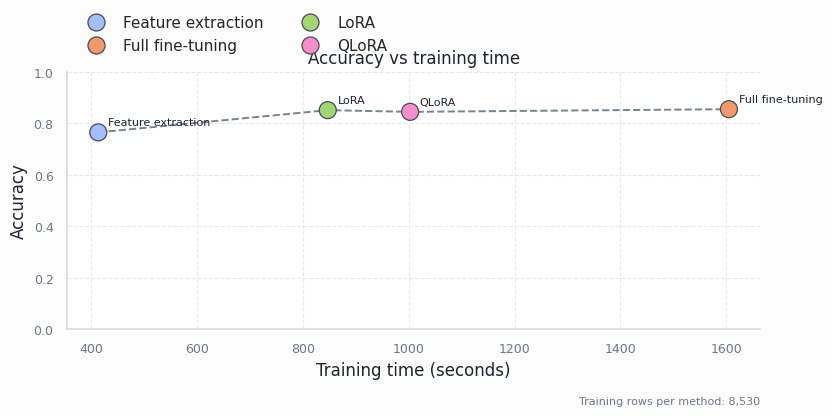

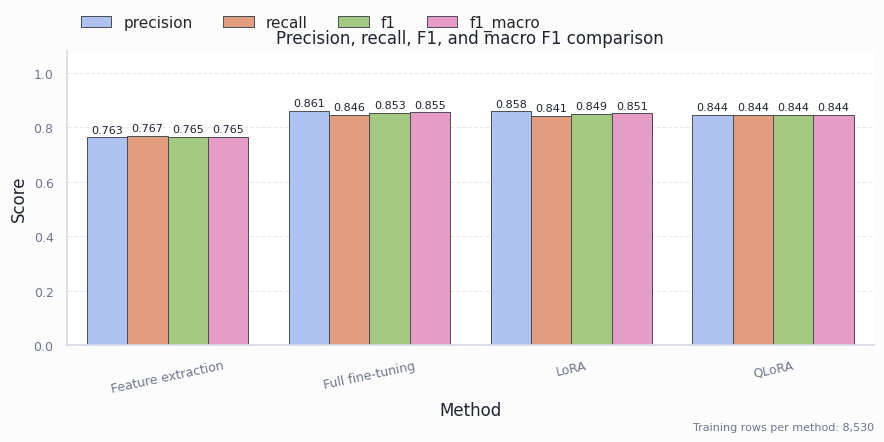

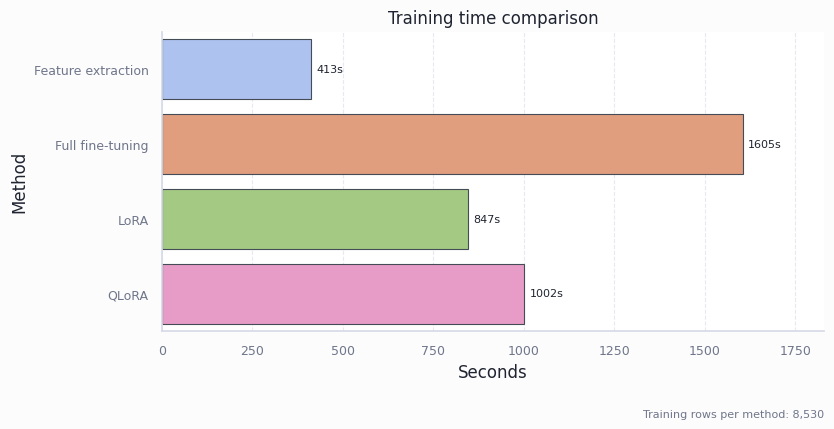

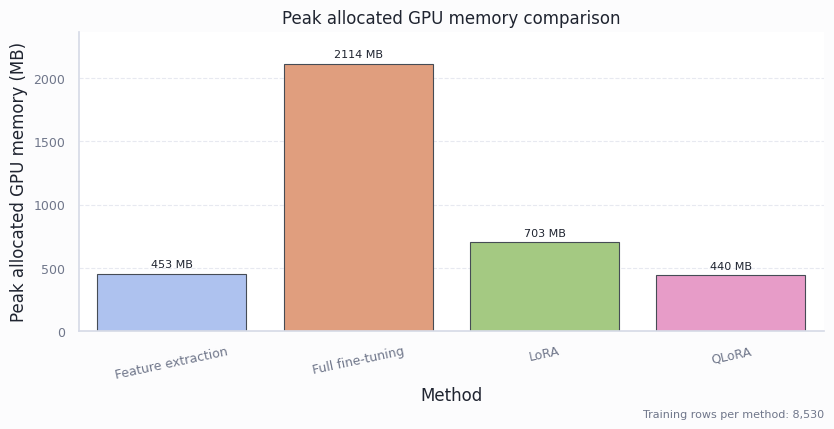

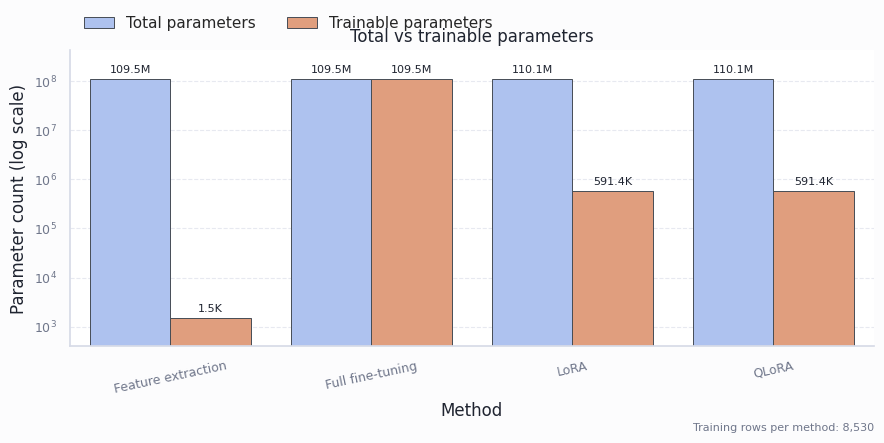

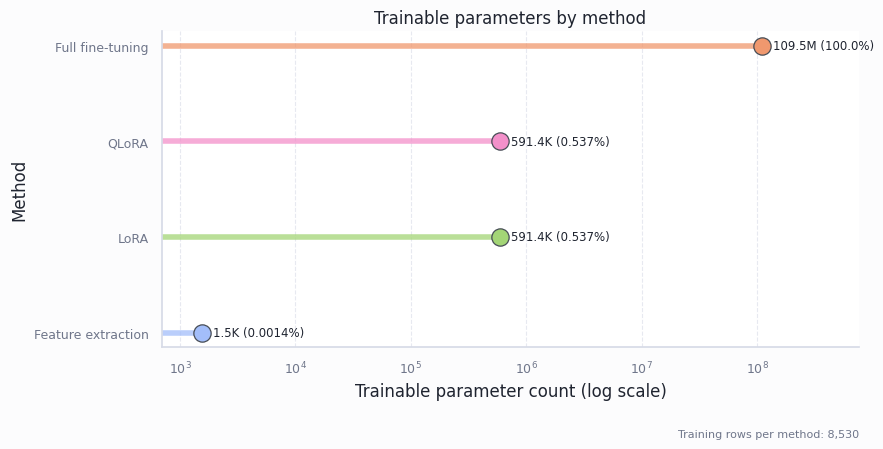

In [26]:
METHOD_ORDER = ["feature_extraction", "finetune", "lora", "qlora"]
METHOD_LABELS = {
    "feature_extraction": "Feature extraction",
    "finetune": "Full fine-tuning",
    "lora": "LoRA",
    "qlora": "QLoRA",
}
METHOD_PALETTE = {
    "Feature extraction": "#A3BEFA",
    "Full fine-tuning": "#F0986E",
    "LoRA": "#A3D576",
    "QLoRA": "#F390CA",
}
METRIC_PALETTE = {"precision": "#A3BEFA", "recall": "#F0986E", "f1": "#A3D576", "f1_macro": "#F390CA"}
PARAM_PALETTE = {"Total parameters": "#A3BEFA", "Trainable parameters": "#F0986E"}
SURFACE_COLOR = "#FCFCFD"
PANEL_COLOR = "#FFFFFF"
INK_COLOR = "#1F2430"
MUTED_COLOR = "#6F768A"
GRID_COLOR = "#E6E8F0"
EDGE_COLOR = "#464C55"

sns.set_theme(
    style="whitegrid",
    rc={
        "figure.facecolor": SURFACE_COLOR,
        "axes.facecolor": PANEL_COLOR,
        "axes.edgecolor": "#D7DBE7",
        "axes.labelcolor": INK_COLOR,
        "axes.titlecolor": INK_COLOR,
        "xtick.color": MUTED_COLOR,
        "ytick.color": MUTED_COLOR,
        "grid.color": GRID_COLOR,
        "grid.linestyle": "--",
        "grid.linewidth": 0.8,
        "font.family": "DejaVu Sans",
    },
)


def bool_series(series: pd.Series) -> pd.Series:
    text = series.astype(str).str.strip().str.lower()
    numeric = pd.to_numeric(series, errors="coerce").fillna(0)
    return text.isin(["true", "1", "1.0", "yes", "y", "t"]) | numeric.eq(1)


def official_plot_results(summary: pd.DataFrame) -> pd.DataFrame:
    status = summary["status"].fillna("ok") if "status" in summary.columns else pd.Series("ok", index=summary.index)
    ok = summary[status.eq("ok")].copy()
    ok = ok[ok["method"].isin(METHOD_ORDER)]
    official = ok[bool_series(ok["is_official_run"])] if "is_official_run" in ok.columns else ok.iloc[0:0].copy()
    if "run_label" in official.columns:
        official = official[official["run_label"].fillna("").eq(RUN_LABEL)]
    if official.empty:
        print("No official results found. Plotting latest available non-official/debug results instead.")
        ok = ok.copy()
        ok["plot_result_source"] = "debug_fallback"
    else:
        ok = official.copy()
        ok["plot_result_source"] = "official"
    if "seed" in ok.columns:
        seed_values = pd.to_numeric(ok["seed"], errors="coerce")
        current_seed_rows = ok[seed_values.eq(SEED)]
        if not current_seed_rows.empty:
            ok = current_seed_rows
    if ok.empty:
        return ok
    ok = ok.sort_values(["method", "seed", "run_name"], na_position="last")
    latest = ok.drop_duplicates("method", keep="last").copy()
    latest["method"] = pd.Categorical(latest["method"], categories=METHOD_ORDER, ordered=True)
    latest = latest.sort_values("method")
    latest["method_label"] = latest["method"].astype(str).map(METHOD_LABELS)
    latest["method_label"] = pd.Categorical(latest["method_label"], categories=list(METHOD_PALETTE), ordered=True)
    if "trainable_percent" not in latest.columns:
        latest["trainable_percent"] = (latest["trainable_parameters"] / latest["total_parameters"]) * 100
    return latest


def style_axis(ax, *, grid_axis="y"):
    ax.set_axisbelow(True)
    if grid_axis == "both":
        ax.grid(True, axis="both", linestyle="--", linewidth=0.8, color=GRID_COLOR, alpha=0.95)
    else:
        ax.grid(True, axis=grid_axis, linestyle="--", linewidth=0.8, color=GRID_COLOR, alpha=0.95)
        ax.grid(False, axis="x" if grid_axis == "y" else "y")
    sns.despine(ax=ax)
    ax.tick_params(colors=MUTED_COLOR, labelsize=9)
    ax.xaxis.label.set_color(INK_COLOR)
    ax.yaxis.label.set_color(INK_COLOR)
    ax.title.set_color(INK_COLOR)
    return ax


def compact_value(value, *, kind="number"):
    if pd.isna(value):
        return ""
    value = float(value)
    if kind == "score":
        return f"{value:.3f}"
    if kind == "seconds":
        return f"{value:.0f}s"
    if kind == "memory":
        return f"{value:.0f} MB"
    if kind == "percent":
        return f"{value:.2f}%"
    abs_value = abs(value)
    if abs_value >= 1_000_000_000:
        return f"{value / 1_000_000_000:.1f}B"
    if abs_value >= 1_000_000:
        return f"{value / 1_000_000:.1f}M"
    if abs_value >= 1_000:
        return f"{value / 1_000:.1f}K"
    return f"{value:.0f}"


def add_bar_labels(ax, *, orientation="v", kind="number", padding=3):
    for container in ax.containers:
        labels = []
        for patch in container.patches:
            value = patch.get_height() if orientation == "v" else patch.get_width()
            labels.append(compact_value(value, kind=kind) if pd.notna(value) else "")
        ax.bar_label(container, labels=labels, padding=padding, fontsize=8, color=INK_COLOR)
    if orientation == "v":
        ax.margins(y=0.12)
    else:
        ax.margins(x=0.14)


def training_rows_note(data: pd.DataFrame) -> str:
    if "dataset_train_rows" not in data.columns or data["dataset_train_rows"].dropna().empty:
        return "Training rows: not recorded"
    train_rows = data["dataset_train_rows"].dropna().astype(int)
    if train_rows.nunique() == 1:
        return f"Training rows per method: {train_rows.iloc[0]:,}"
    parts = [f"{row['method_label']}: {int(row['dataset_train_rows']):,}" for _, row in data.dropna(subset=["dataset_train_rows"]).iterrows()]
    return "Training rows: " + " | ".join(parts)


def add_training_rows_note(ax, data: pd.DataFrame):
    ax.text(
        1.0,
        -0.26,
        training_rows_note(data),
        transform=ax.transAxes,
        ha="right",
        va="top",
        fontsize=8,
        color=MUTED_COLOR,
    )


def save_and_show(filename: str):
    path = FIGURES_DIR / filename
    plt.tight_layout()
    plt.savefig(path, dpi=180, bbox_inches="tight", facecolor=SURFACE_COLOR)
    plt.show()
    return path


latest = official_plot_results(summary)

if latest.empty:
    print("No official results found yet. Set IS_OFFICIAL_RUN = True, run the experiments, then rerun this comparison cell.")
else:
    comparison_columns = [
        "method",
        "seed",
        "run_label",
        "is_official_run",
        "evaluation_split",
        "dataset_train_rows",
        "accuracy",
        "precision",
        "recall",
        "f1",
        "f1_macro",
        "training_time_seconds",
        "peak_gpu_allocated_mb",
        "peak_gpu_reserved_mb",
        "total_parameters",
        "trainable_parameters",
    ]
    display(latest[[col for col in comparison_columns if col in latest.columns]])

    # 1) Accuracy against training time for the four methods.
    accuracy_time = latest.dropna(subset=["training_time_seconds", "accuracy"]).sort_values("training_time_seconds")
    if not accuracy_time.empty:
        fig, ax = plt.subplots(figsize=(8.5, 4.6))
        ax.plot(
            accuracy_time["training_time_seconds"],
            accuracy_time["accuracy"],
            color="#7A828F",
            linewidth=1.4,
            linestyle="--",
            zorder=1,
        )
        sns.scatterplot(
            data=accuracy_time,
            x="training_time_seconds",
            y="accuracy",
            hue="method_label",
            palette=METHOD_PALETTE,
            s=150,
            edgecolor=EDGE_COLOR,
            linewidth=0.9,
            ax=ax,
            zorder=2,
        )
        for _, row in accuracy_time.iterrows():
            ax.annotate(str(row["method_label"]), (row["training_time_seconds"], row["accuracy"]), xytext=(7, 5), textcoords="offset points", fontsize=8, color=INK_COLOR)
        ax.set_title("Accuracy vs training time")
        ax.set_xlabel("Training time (seconds)")
        ax.set_ylabel("Accuracy")
        ax.set_ylim(0, 1)
        ax.legend(title="", loc="lower left", bbox_to_anchor=(0, 1.02), ncol=2, frameon=False)
        style_axis(ax, grid_axis="both")
        add_training_rows_note(ax, accuracy_time)
        save_and_show("notebook_accuracy_line_comparison.png")

    # 2) Grouped bar chart for Precision, Recall, F1, and Macro F1.
    score_cols = [col for col in ["precision", "recall", "f1", "f1_macro"] if col in latest.columns and latest[col].notna().any()]
    scores_long = latest.melt(id_vars="method_label", value_vars=score_cols, var_name="metric", value_name="score")
    fig, ax = plt.subplots(figsize=(9, 4.8))
    sns.barplot(data=scores_long, x="method_label", y="score", hue="metric", palette=METRIC_PALETTE, edgecolor=EDGE_COLOR, linewidth=0.7, ax=ax)
    add_bar_labels(ax, kind="score", padding=2)
    ax.set_title("Precision, recall, F1, and macro F1 comparison")
    ax.set_xlabel("Method")
    ax.set_ylabel("Score")
    ax.set_ylim(0, 1.08)
    ax.legend(title="", loc="lower left", bbox_to_anchor=(0, 1.02), ncol=len(score_cols), frameon=False)
    ax.tick_params(axis="x", rotation=12)
    style_axis(ax, grid_axis="y")
    add_training_rows_note(ax, latest)
    save_and_show("notebook_classification_scores_grouped_bar.png")

    # 3) Horizontal bar chart for training time.
    if latest["training_time_seconds"].notna().any():
        time_plot = latest.dropna(subset=["training_time_seconds"]).sort_values("training_time_seconds", ascending=True)
        fig, ax = plt.subplots(figsize=(8.5, 4.6))
        sns.barplot(data=time_plot, y="method_label", x="training_time_seconds", hue="method_label", palette=METHOD_PALETTE, legend=False, orient="h", edgecolor=EDGE_COLOR, linewidth=0.8, ax=ax)
        add_bar_labels(ax, orientation="h", kind="seconds", padding=4)
        ax.set_title("Training time comparison")
        ax.set_xlabel("Seconds")
        ax.set_ylabel("Method")
        style_axis(ax, grid_axis="x")
        add_training_rows_note(ax, time_plot)
        save_and_show("notebook_training_time_horizontal_bar.png")

    # 4) GPU memory bar chart.
    memory_col = "peak_gpu_allocated_mb" if "peak_gpu_allocated_mb" in latest.columns and latest["peak_gpu_allocated_mb"].notna().any() else "peak_gpu_memory_mb"
    if latest[memory_col].notna().any():
        memory_plot = latest.dropna(subset=[memory_col])
        fig, ax = plt.subplots(figsize=(8.5, 4.6))
        sns.barplot(data=memory_plot, x="method_label", y=memory_col, hue="method_label", palette=METHOD_PALETTE, legend=False, edgecolor=EDGE_COLOR, linewidth=0.8, ax=ax)
        add_bar_labels(ax, kind="memory", padding=3)
        ax.set_title("Peak allocated GPU memory comparison")
        ax.set_xlabel("Method")
        ax.set_ylabel("Peak allocated GPU memory (MB)")
        ax.tick_params(axis="x", rotation=12)
        style_axis(ax, grid_axis="y")
        add_training_rows_note(ax, memory_plot)
        save_and_show("notebook_gpu_memory_bar.png")

    # 5) Total vs trainable parameters, log scale.
    param_cols = ["total_parameters", "trainable_parameters"]
    params_long = latest.melt(id_vars="method_label", value_vars=param_cols, var_name="parameter_type", value_name="count")
    params_long["parameter_type"] = params_long["parameter_type"].map({"total_parameters": "Total parameters", "trainable_parameters": "Trainable parameters"})
    fig, ax = plt.subplots(figsize=(9, 4.8))
    sns.barplot(data=params_long, x="method_label", y="count", hue="parameter_type", palette=PARAM_PALETTE, edgecolor=EDGE_COLOR, linewidth=0.7, ax=ax)
    ax.set_yscale("log")
    add_bar_labels(ax, kind="number", padding=3)
    ax.set_title("Total vs trainable parameters")
    ax.set_xlabel("Method")
    ax.set_ylabel("Parameter count (log scale)")
    ax.legend(title="", loc="lower left", bbox_to_anchor=(0, 1.02), ncol=2, frameon=False)
    ax.tick_params(axis="x", rotation=12)
    style_axis(ax, grid_axis="y")
    add_training_rows_note(ax, latest)
    save_and_show("notebook_parameters_log_bar.png")

    # 6) Trainable parameter count on a log scale.
    if latest["trainable_parameters"].notna().any():
        trainable_plot = latest.dropna(subset=["trainable_parameters"]).sort_values("trainable_parameters", ascending=True)
        fig, ax = plt.subplots(figsize=(9, 4.8))
        y_positions = range(len(trainable_plot))
        x_start = max(1, trainable_plot["trainable_parameters"].min() * 0.45)

        for y, (_, row) in zip(y_positions, trainable_plot.iterrows()):
            color = METHOD_PALETTE[str(row["method_label"])]
            ax.hlines(y=y, xmin=x_start, xmax=row["trainable_parameters"], color=color, linewidth=4, alpha=0.75)
            ax.scatter(row["trainable_parameters"], y, s=155, color=color, edgecolor=EDGE_COLOR, linewidth=0.9, zorder=3)
            percent = row["trainable_percent"]
            percent_label = f"{percent:.4f}%" if percent < 0.01 else f"{percent:.3f}%" if percent < 1 else f"{percent:.1f}%"
            ax.annotate(
                f"{compact_value(row['trainable_parameters'])} ({percent_label})",
                (row["trainable_parameters"], y),
                xytext=(8, 0),
                textcoords="offset points",
                va="center",
                fontsize=8.5,
                color=INK_COLOR,
            )

        ax.set_xscale("log")
        ax.set_xlim(x_start, trainable_plot["trainable_parameters"].max() * 7)
        ax.set_yticks(list(y_positions), trainable_plot["method_label"].astype(str))
        ax.set_title("Trainable parameters by method")
        ax.set_xlabel("Trainable parameter count (log scale)")
        ax.set_ylabel("Method")
        style_axis(ax, grid_axis="x")
        add_training_rows_note(ax, trainable_plot)
        save_and_show("notebook_trainable_percent_histplot.png")


## 12. Official diagnostics

These diagnostics use official runs only.

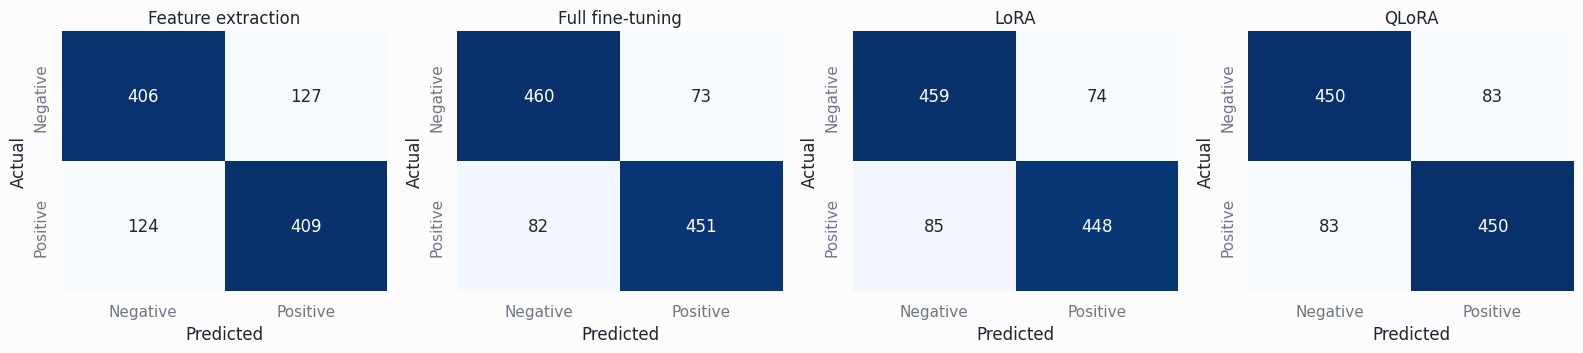

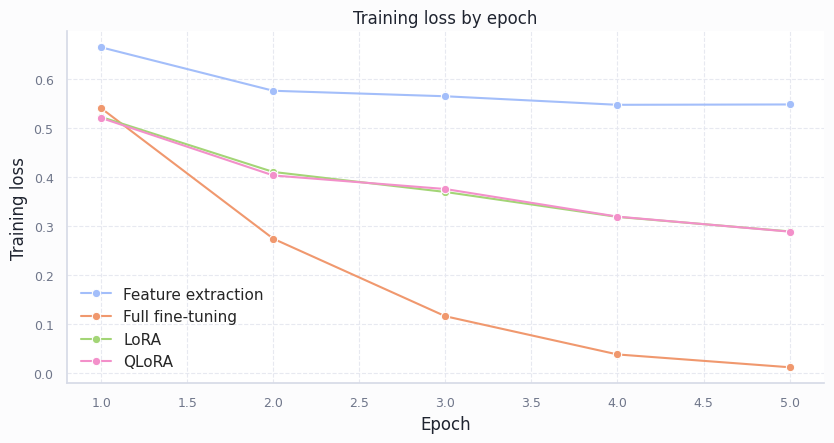

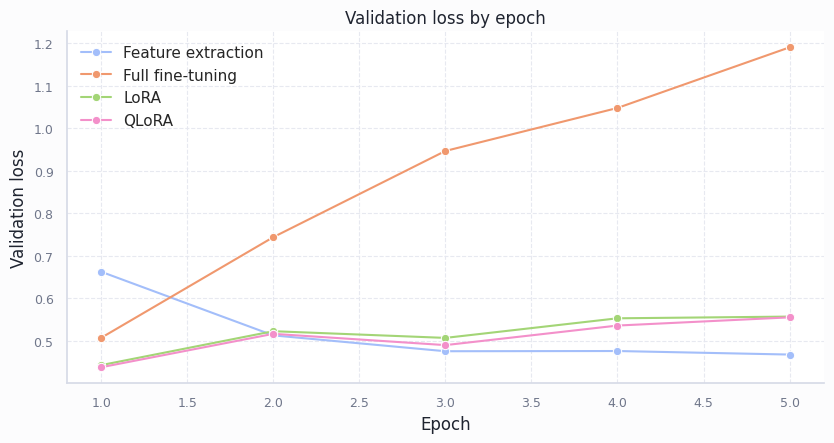

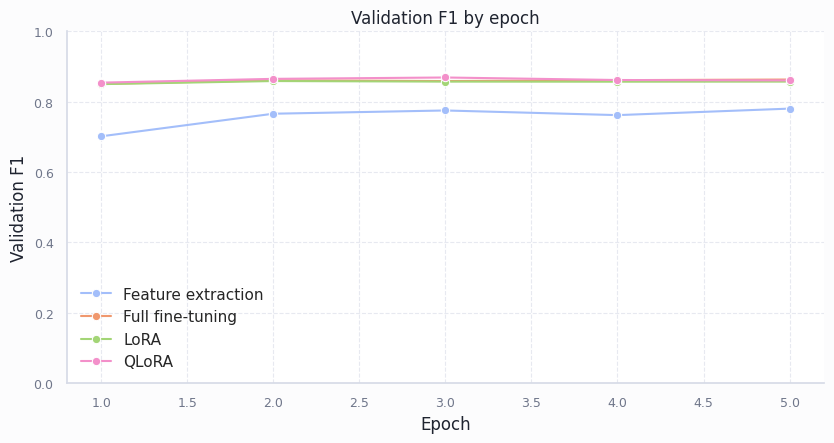

In [27]:
diagnostic_results = official_plot_results(summary) if "official_plot_results" in globals() else pd.DataFrame()

if diagnostic_results.empty:
    print("No official results found yet. Set IS_OFFICIAL_RUN = True and run the experiments before generating diagnostics.")
else:
    # Confusion matrix for each method.
    cm_rows = diagnostic_results.dropna(subset=["confusion_matrix_path"]).copy()
    if not cm_rows.empty:
        fig, axes = plt.subplots(1, len(cm_rows), figsize=(4 * len(cm_rows), 3.7), squeeze=False)
        for ax, (_, row) in zip(axes.flat, cm_rows.iterrows()):
            with open(row["confusion_matrix_path"], "r", encoding="utf-8") as f:
                payload = json.load(f)
            matrix = np.array(payload["matrix"])
            sns.heatmap(
                matrix,
                annot=True,
                fmt="d",
                cmap="Blues",
                cbar=False,
                xticklabels=["Negative", "Positive"],
                yticklabels=["Negative", "Positive"],
                ax=ax,
            )
            ax.set_title(str(row["method_label"]))
            ax.set_xlabel("Predicted")
            ax.set_ylabel("Actual")
        plt.tight_layout()
        plt.savefig(FIGURES_DIR / "official_confusion_matrices.png", dpi=180, bbox_inches="tight")
        plt.show()

    history_frames = []
    for _, row in diagnostic_results.dropna(subset=["log_history_path"]).iterrows():
        history_path = Path(row["log_history_path"])
        if not history_path.exists():
            continue
        history = pd.read_csv(history_path)
        history["method"] = row["method"]
        history["method_label"] = row["method_label"]
        history["seed"] = row["seed"]
        history_frames.append(history)

    if history_frames:
        history = pd.concat(history_frames, ignore_index=True)

        train_loss = history.dropna(subset=["loss", "epoch"]).copy()
        if not train_loss.empty:
            train_loss["epoch_bin"] = np.ceil(train_loss["epoch"]).astype(int)
            train_loss = train_loss.sort_values(["method", "epoch"]).groupby(["method", "method_label", "epoch_bin"], as_index=False).tail(1)
            fig, ax = plt.subplots(figsize=(8.5, 4.6))
            sns.lineplot(data=train_loss, x="epoch_bin", y="loss", hue="method_label", marker="o", palette=METHOD_PALETTE, ax=ax)
            ax.set_title("Training loss by epoch")
            ax.set_xlabel("Epoch")
            ax.set_ylabel("Training loss")
            ax.legend(title="", loc="best", frameon=False)
            style_axis(ax, grid_axis="both")
            plt.tight_layout()
            plt.savefig(FIGURES_DIR / "official_training_loss_by_epoch.png", dpi=180, bbox_inches="tight")
            plt.show()

        validation_loss = history.dropna(subset=["eval_loss", "epoch"]).copy()
        if not validation_loss.empty:
            fig, ax = plt.subplots(figsize=(8.5, 4.6))
            sns.lineplot(data=validation_loss, x="epoch", y="eval_loss", hue="method_label", marker="o", palette=METHOD_PALETTE, ax=ax)
            ax.set_title("Validation loss by epoch")
            ax.set_xlabel("Epoch")
            ax.set_ylabel("Validation loss")
            ax.legend(title="", loc="best", frameon=False)
            style_axis(ax, grid_axis="both")
            plt.tight_layout()
            plt.savefig(FIGURES_DIR / "official_validation_loss_by_epoch.png", dpi=180, bbox_inches="tight")
            plt.show()

        validation_f1 = history.dropna(subset=["eval_f1", "epoch"]).copy()
        if not validation_f1.empty:
            fig, ax = plt.subplots(figsize=(8.5, 4.6))
            sns.lineplot(data=validation_f1, x="epoch", y="eval_f1", hue="method_label", marker="o", palette=METHOD_PALETTE, ax=ax)
            ax.set_title("Validation F1 by epoch")
            ax.set_xlabel("Epoch")
            ax.set_ylabel("Validation F1")
            ax.set_ylim(0, 1)
            ax.legend(title="", loc="best", frameon=False)
            style_axis(ax, grid_axis="both")
            plt.tight_layout()
            plt.savefig(FIGURES_DIR / "official_validation_f1_by_epoch.png", dpi=180, bbox_inches="tight")
            plt.show()
    else:
        print("No log history files found for official results yet.")